# 01 — Data Preprocessing
**Project**: Automated Customer Reviews — IronHack  
**Dataset**: [Kaggle — Consumer Reviews of Amazon Products](https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products/data)

**Goal**: Load the 3 raw CSV files, merge them, keep only the columns we need, clean the data, and save a single clean CSV ready for the next notebooks.

**Columns we keep**:
| Column | Used for |
|--------|----------|
| `product_name` | Summarization |
| `brand` | Summarization |
| `rating` | Ground truth for BERT evaluation |
| `review_title` | Extra context for BERT |
| `review_text` | Sentiment · Clustering · Summarization |

---

## 1. Imports

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

# ── Plot style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}

# ── Output folders ──────────────────────────────────────────
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/plots',     exist_ok=True)

print('✅ Imports done')

✅ Imports done


## 2. Load the 3 Raw CSV Files

In [3]:
DATA_DIR = '/Users/domiendarmont/Desktop/project_rev.aggre./data/data_raw'  
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print(f'Found {len(csv_files)} CSV files:\n')

dataframes = []
for file_name in csv_files:
    path   = os.path.join(DATA_DIR, file_name)
    df_tmp = pd.read_csv(path, low_memory=False)
    dataframes.append(df_tmp)
    print(f'  📄 {file_name}')
    print(f'     rows    : {df_tmp.shape[0]:>7,}')
    print(f'     columns : {df_tmp.shape[1]:>7}')
    print(f'     cols    : {df_tmp.columns.tolist()}\n')

Found 3 CSV files:

  📄 data_1.csv
     rows    :  34,660
     columns :      21
     cols    : ['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']

  📄 data_2.csv
     rows    :  28,332
     columns :      24
     cols    : ['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs']

  📄 data_3.csv
     rows    :   5,000
     columns :      24
     cols    : ['id', 'dateAdded', 'da

## 3. Concatenate Into One DataFrame

All 3 files share the same column structure — we stack them vertically with `pd.concat`.

In [4]:
df_raw = pd.concat(dataframes, ignore_index=True, sort=False)

print(f'Total rows after merging : {df_raw.shape[0]:,}')
print(f'Total columns            : {df_raw.shape[1]}')
df_raw.head(3)

Total rows after merging : 67,992
Total columns            : 27


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,dateAdded,dateUpdated,primaryCategories,imageURLs,manufacturerNumber,sourceURLs
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoff...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406...",This product so far has not disappointed. My children love to use it and I like the ability to monitor control what ...,Kindle,NaN,NaN,Adapter,NaN,NaN,NaN,NaN,NaN,NaN
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoff...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406...",great for beginner or experienced person. Bought as a gift and she loves it,very fast,NaN,NaN,truman,NaN,NaN,NaN,NaN,NaN,NaN
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoff...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406...","Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype o...",Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Select & Rename the 5 Columns We Need

In [5]:
# ── Map original column names → clean names ──────────────────
# Adjust the LEFT side if your CSV uses slightly different names
COLUMN_MAP = {
    'name'           : 'product_name',
    'brand'          : 'brand',
    'reviews.rating' : 'rating',
    'reviews.title'  : 'review_title',
    'reviews.text'   : 'review_text',
}

# Only keep columns that actually exist in the raw data
existing = {orig: new for orig, new in COLUMN_MAP.items() if orig in df_raw.columns}
df = df_raw[list(existing.keys())].rename(columns=existing).copy()

print(f'Columns kept : {df.columns.tolist()}')
print(f'Shape        : {df.shape}')
df.head(3)

Columns kept : ['product_name', 'brand', 'rating', 'review_title', 'review_text']
Shape        : (67992, 5)


,product_name,brand,rating,review_title,review_text
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,5.0,Kindle,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what ...
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,5.0,very fast,great for beginner or experienced person. Bought as a gift and she loves it
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,5.0,Beginner tablet for our 9 year old son.,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype o..."


## 5. Data Cleaning

In [6]:
print(f'Rows before cleaning: {len(df):,}\n')

# 1. Drop rows with no review text — nothing we can do without it
df = df.dropna(subset=['review_text'])
print(f'After dropping missing review_text  : {len(df):,}')

# 5. Clean product names — remove duplicate lines and trailing commas
df['product_name'] = (
    df['product_name']
    .str.split('\n').str[0]   # keep only first line if duplicated
    .str.strip(',')            # remove trailing commas
    .str.strip()               # remove whitespace
)

# 2. Drop rows with no rating — needed for BERT evaluation later
df = df.dropna(subset=['rating'])
print(f'After dropping missing rating       : {len(df):,}')

# 3. Remove exact duplicate review texts
df = df.drop_duplicates(subset=['review_text'])
print(f'After removing duplicate reviews    : {len(df):,}')

# 4. Convert rating to integer (some CSVs store it as float)
df['rating'] = df['rating'].astype(int)

# 5. Strip leading/trailing whitespace from text columns
df['review_text']  = df['review_text'].str.strip()
df['review_title'] = df['review_title'].str.strip()

# 6. Remove very short reviews (< 15 characters) — pure noise
df = df[df['review_text'].str.len() >= 15]
print(f'After removing very short reviews   : {len(df):,}')

# 7. Only keep valid ratings (1-5)
df = df[df['rating'].between(1, 5)]
print(f'After keeping only ratings 1-5      : {len(df):,}')

print(f'\n✅ Rows removed total: {df_raw.shape[0] - len(df):,}')

Rows before cleaning: 67,992

After dropping missing review_text  : 67,991
After dropping missing rating       : 67,958
After removing duplicate reviews    : 46,876
After removing very short reviews   : 46,169
After keeping only ratings 1-5      : 46,169

✅ Rows removed total: 21,823


## 6. Map Star Ratings → Ground Truth Sentiment Labels

These labels are **only used to evaluate BERT** in notebook 02.  
BERT reads the review text and predicts sentiment on its own.  
We compare BERT's predictions against these labels to measure accuracy.

| Stars | Ground Truth Label |
|-------|-------------------|
| ⭐ 1–2 | `negative` |
| ⭐⭐⭐ 3 | `neutral` |
| ⭐⭐⭐⭐⭐ 4–5 | `positive` |

In [7]:
def map_rating_to_sentiment(rating: int) -> str:
    """Map a 1-5 star rating to a sentiment label used as ground truth."""
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['ground_truth'] = df['rating'].apply(map_rating_to_sentiment)

label_counts = df['ground_truth'].value_counts()
label_pct    = df['ground_truth'].value_counts(normalize=True).mul(100).round(1)

print('Ground truth label distribution:')
for label in ['positive', 'neutral', 'negative']:
    bar = '█' * int(label_pct[label] / 2)
    print(f'  {label:<10} {label_counts[label]:>6,}  ({label_pct[label]:>5.1f}%)  {bar}')

Ground truth label distribution:
  positive   42,321  ( 91.7%)  █████████████████████████████████████████████
  neutral     2,029  (  4.4%)  ██
  negative    1,819  (  3.9%)  █


## 7. Exploratory Data Analysis (EDA)

Three plots that answer three questions:
1. **How did customers rate products?** — raw star distribution
2. **How balanced are our sentiment labels?** — important for BERT evaluation
3. **How long are the reviews?** — impacts BERT token limits

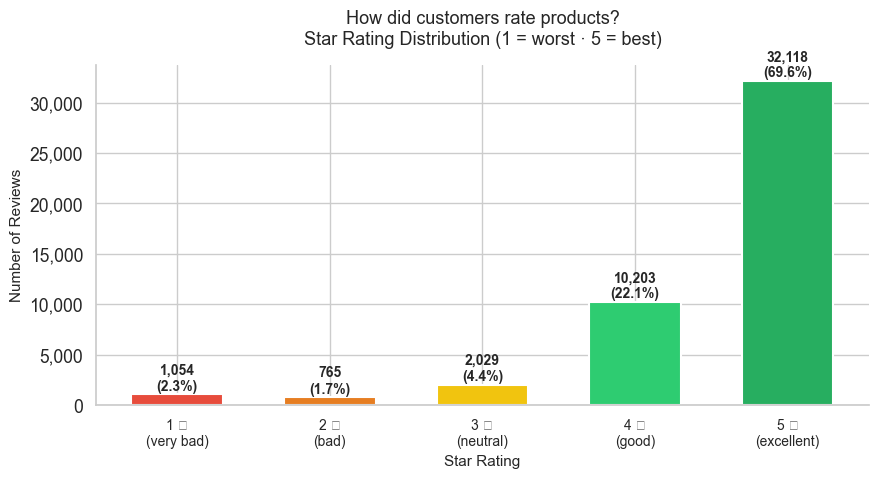

Insight: The dataset is heavily skewed towards 5-star reviews.


In [8]:
# ── Plot 1: Star Rating Distribution ────────────────────────
rating_counts = df['rating'].value_counts().sort_index()
star_colors   = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=star_colors, edgecolor='white', linewidth=1.5, width=0.6)

# Count + percentage above each bar
total = rating_counts.sum()
for bar, count in zip(bars, rating_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.003,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('How did customers rate products?\nStar Rating Distribution (1 = worst · 5 = best)',
             fontsize=13, pad=15)
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1 ⭐\n(very bad)', '2 ⭐\n(bad)', '3 ⭐\n(neutral)',
                    '4 ⭐\n(good)', '5 ⭐\n(excellent)'], fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()

plt.tight_layout()
plt.savefig('../data/plots/01_star_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: The dataset is heavily skewed towards 5-star reviews.')

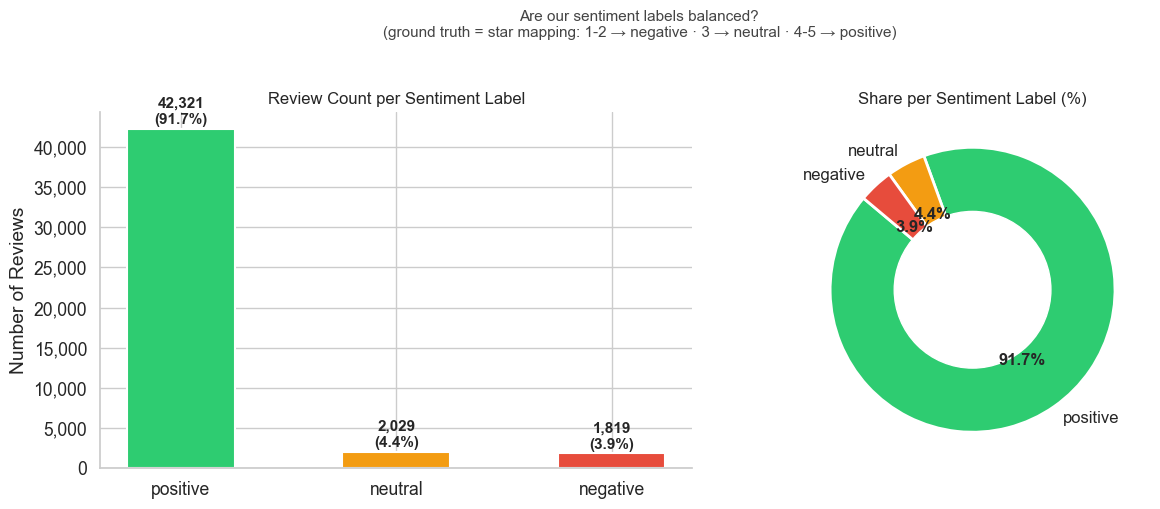

Insight: Dataset is imbalanced — mostly positive. BERT evaluation metrics per class will matter more than overall accuracy.


In [9]:
# ── Plot 2: Sentiment Label Balance ─────────────────────────
order  = ['positive', 'neutral', 'negative']
counts = df['ground_truth'].value_counts().reindex(order)
colors = [PALETTE[l] for l in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Are our sentiment labels balanced?\n'
    '(ground truth = star mapping: 1-2 → negative · 3 → neutral · 4-5 → positive)',
    fontsize=11, color='#444444', y=1.02
)

# Bar chart
bars = axes[0].bar(order, counts.values, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, counts.values):
    pct = count / counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + counts.sum() * 0.005,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Review Count per Sentiment Label', fontsize=12)
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=axes[0])

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=order, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[1].add_patch(centre_circle)
axes[1].set_title('Share per Sentiment Label (%)', fontsize=12)

plt.tight_layout()
plt.savefig('../data/plots/02_sentiment_label_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Dataset is imbalanced — mostly positive. BERT evaluation metrics per class will matter more than overall accuracy.')

## 9. Save Clean Dataset

In [10]:
OUTPUT_PATH = '/Users/domiendarmont/Desktop/project_rev.aggre./data/data_processed' \
+'reviews_clean.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Clean dataset saved to : {OUTPUT_PATH}')
print(f'   Rows    : {len(df):,}')
print(f'   Columns : {df.columns.tolist()}')

✅ Clean dataset saved to : /Users/domiendarmont/Desktop/project_rev.aggre./data/data_processedreviews_clean.csv
   Rows    : 46,169
   Columns : ['product_name', 'brand', 'rating', 'review_title', 'review_text', 'ground_truth']


## 10. Summary

| Step | Details |
|------|---------|
| Source files | 3 CSV files from Kaggle |
| Merge strategy | `pd.concat` — vertical stack (same columns) |
| Columns kept | `product_name`, `brand`, `rating`, `review_title`, `review_text`, `ground_truth` |
| Cleaning steps | Dropped nulls · duplicates · short reviews · invalid ratings |
| Ground truth labels | `positive` (4-5⭐) · `neutral` (3⭐) · `negative` (1-2⭐) |
| Output | `../data/processed/reviews_clean.csv` |

➡️ **Next**: `02_sentiment_classification.ipynb` — BERT reads the review text and predicts sentiment, we compare to `ground_truth`.

Next codeblock to get the url's to the pictures for our deployment app.

In [12]:


DATA_DIR = '/Users/domiendarmont/Desktop/project_rev.aggre./data/data_raw'
dfs = []
for f in sorted(os.listdir(DATA_DIR)):
    if f.endswith('.csv'):
        df = pd.read_csv(os.path.join(DATA_DIR, f), low_memory=False)
        if 'imageURLs' in df.columns and 'name' in df.columns:
            dfs.append(df[['name', 'imageURLs']].dropna())

image_map = pd.concat(dfs).drop_duplicates(subset=['name'])
image_map.columns = ['product_name', 'image_url']
image_map['product_name'] = (
    image_map['product_name']
    .str.split('\n').str[0]
    .str.replace(r',+$', '', regex=True)
    .str.strip()
)
image_map.to_csv('../data/processed/product_images.csv', index=False)
print(f'✅ {len(image_map):,} product images saved')
print(image_map.head(3))

✅ 79 product images saved
                                                    product_name  \
0     AmazonBasics AAA Performance Alkaline Batteries (36 Count)   
8343             AmazonBasics Nylon CD/DVD Binder (400 Capacity)   
8347                                       Amazon Echo ‚Äì White   

                                                                                                                    image_url  
0     https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/...  
8343  http://ecx.images-amazon.com/images/I/41jQha7Z7VL._SS40_.jpg,https://i.ebayimg.com/images/g/fzIAAOSwyHJcfeFd/s-l64.j...  
8347  https://i.ebayimg.com/images/g/NWEAAOSwDehbdx6M/s-l140.jpg,https://static.bhphoto.com/images/images500x500/amazon_b0...  
